# 06. Permutation, Randomization, and Exact Inference

Notebook 05 emphasized how much everyday testing depends on large-sample approximations and on habits around p-values. We step into a different inferential world. The **assignment mechanism itself** can generate the reference distribution for what is surprising.

That shift matters most when samples are small, outcomes are skewed, and the design is trustworthy. In those settings, exact randomization inference can give us a cleaner answer than an asymptotic test, because it is closely tied to how the data were actually produced.

We will work through a deliberately small randomized operations pilot and use it to connect four ideas:

1. why randomization can be the basis for exact inference,
2. how permutation-style calculations are related to randomized experiments,
3. why exact and asymptotic tests can disagree in finite samples,
4. how to invert exact tests to obtain a finite-sample confidence interval for a constant treatment effect.


## Learning Objectives

After working through this lecture, you should be able to:

1. Explain the difference between asymptotic testing logic and exact randomization logic.
2. State what a **sharp null** is and why it makes exact testing possible.
3. Construct the randomization distribution of a difference-in-means statistic by enumerating all allowed assignments.
4. Compare an exact randomization p-value with an asymptotic Welch t-test in a small, skewed sample.
5. Use Monte Carlo sampling to approximate a randomization distribution when exhaustive enumeration is expensive.
6. Invert sharp-null tests to obtain an exact confidence interval for a constant additive treatment effect.
7. Explain how Fisher's exact test fits into the same design-based family of ideas.
8. Write a decision memo that uses exact inference without overstating what a small pilot can prove.


In [1]:
# Load the libraries and notebook settings used in the examples below.
import itertools
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from notebooks._shared.display import smart_display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f"{x:0.3f}")
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 160)
np.random.seed(2026)


def build_queue_pilot(seed=7):
    """
    Create a small randomized pilot dataset with skewed operational outcomes.
    
    Parameters:
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A pandas DataFrame representing the small randomized queue-management pilot used for exact inference.
    
    Idea:
        Construct a small randomized pilot with known assignment logic so later inference can be tied to the design before modeling assumptions enter.
    """
    rng = np.random.default_rng(seed)
    n_units = 16

    latent_pressure = rng.normal(0, 1, size=n_units)
    control_minutes = 30 + 4 * latent_pressure + rng.gamma(shape=1.5, scale=5.0, size=n_units)
    gains_from_playbook = 3 + 2 * (latent_pressure > 0) + rng.normal(0, 1, size=n_units)
    treated_minutes = control_minutes - gains_from_playbook

    assignment = np.zeros(n_units, dtype=int)
    assignment[rng.choice(n_units, size=n_units // 2, replace=False)] = 1
    observed_minutes = np.where(assignment == 1, treated_minutes, control_minutes)

    pilot = pd.DataFrame(
        {
            'team': [f'Team {i:02d}' for i in range(1, n_units + 1)],
            'latent_pressure': latent_pressure,
            'control_minutes': control_minutes,
            'treated_minutes': treated_minutes,
            'true_effect_minutes': treated_minutes - control_minutes,
            'assigned_playbook': np.where(assignment == 1, 'New playbook', 'Status quo'),
            'treated': assignment,
            'observed_minutes': observed_minutes,
        }
    )
    pilot['bad_week'] = (pilot['observed_minutes'] > 35).astype(int)
    return pilot


def build_assignment_matrix(n_units, n_treated):
    """
    Enumerate all treatment assignments allowed by a complete-randomization design.
    
    Parameters:
        n_units: Number of experimental units in the pilot.
        n_treated: Number of units assigned to treatment in every allowed assignment.
    
    Returns:
        A NumPy array whose rows are binary treatment-assignment vectors with exactly `n_treated` treated units.
    
    Idea:
        Make the design explicit. Exact randomization inference compares the observed statistic with statistics from assignments the experiment could actually have produced.
    """
    treated_combinations = list(itertools.combinations(range(n_units), n_treated))
    assignment_matrix = np.zeros((len(treated_combinations), n_units), dtype=np.int8)
    row_index = np.arange(len(treated_combinations))
    assignment_matrix[row_index[:, None], np.array(treated_combinations)] = 1
    return assignment_matrix


def diff_in_means(values, assignment):
    """
    Compute the treated-minus-control difference in group means.
    
    Parameters:
        values: Observed or sharp-null-adjusted outcomes for the experimental units.
        assignment: Binary treatment labels where 1 marks treated units and 0 marks control units.
    
    Returns:
        The treated-minus-control mean difference for the supplied outcomes and assignment labels.
    
    Idea:
        Use the same contrast for the observed assignment and every reassignment, so the reference distribution is comparable to the observed statistic.
    """
    treated = assignment == 1
    control = ~treated
    return float(values[treated].mean() - values[control].mean())


def randomization_distribution(adjusted_outcomes, assignment_matrix):
    """
    Compute the randomization distribution of the difference-in-means statistic.
    
    Parameters:
        adjusted_outcomes: Outcomes after applying the sharp-null adjustment for a hypothesized treatment effect.
        assignment_matrix: Matrix whose rows are the treatment assignments allowed by the experimental design.
    
    Returns:
        A NumPy array containing the difference-in-means statistic for every allowed assignment.
    
    Idea:
        Build the finite-sample reference distribution directly from the randomized design instead of a large-sample approximation.
    """
    n_units = assignment_matrix.shape[1]
    n_treated = int(assignment_matrix[0].sum())
    n_control = n_units - n_treated

    treated_sums = assignment_matrix @ adjusted_outcomes
    control_sums = adjusted_outcomes.sum() - treated_sums
    return treated_sums / n_treated - control_sums / n_control


def exact_randomization_test(observed_outcomes, observed_assignment, assignment_matrix, tau0=0.0):
    """
    Run an exact two-sided randomization test for a sharp constant-effect null.
    
    Parameters:
        observed_outcomes: Observed outcomes under the realized treatment assignment.
        observed_assignment: Realized binary treatment labels for the pilot units.
        assignment_matrix: Matrix of all treatment assignments allowed by the design.
        tau0: Hypothesized constant treatment effect subtracted from treated outcomes before reassignment.
    
    Returns:
        A dictionary with the adjusted outcomes, observed statistic, full randomization distribution, and exact p-value.
    
    Idea:
        Use the assignment mechanism itself as the reference distribution, which is the cleanest inferential logic for a small randomized experiment.
    """
    adjusted_outcomes = observed_outcomes - tau0 * observed_assignment
    observed_stat = diff_in_means(adjusted_outcomes, observed_assignment)
    distribution = randomization_distribution(adjusted_outcomes, assignment_matrix)
    p_value = np.mean(np.abs(distribution) >= abs(observed_stat) - 1e-12)

    return {
        'adjusted_outcomes': adjusted_outcomes,
        'observed_stat': float(observed_stat),
        'distribution': distribution,
        'p_value': float(p_value),
    }


def monte_carlo_randomization_summary(adjusted_outcomes, observed_stat, assignment_matrix, draws_grid=(200, 500, 1_000, 2_000, 5_000), n_rep=20, seed=2026):
    """
    Study how Monte Carlo randomization p-values stabilize as sampled assignments increase.
    
    Parameters:
        adjusted_outcomes: Sharp-null-adjusted outcomes used as fixed outcomes under reassignment.
        observed_stat: Observed difference-in-means statistic defining the two-sided tail event.
        assignment_matrix: Matrix of all treatment assignments allowed by the randomized design.
        draws_grid: Monte Carlo draw counts to evaluate.
        n_rep: Number of independent Monte Carlo estimates computed for each draw count.
        seed: Random seed used to make the Monte Carlo comparison reproducible.
    
    Returns:
        A tuple containing detailed Monte Carlo estimates and a compact summary table by draw count.
    
    Idea:
        Separate design-based inference from computational approximation by showing that sampled assignments converge toward the exact finite-assignment answer.
    """
    rng = np.random.default_rng(seed)
    n_units = assignment_matrix.shape[1]
    n_treated = int(assignment_matrix[0].sum())
    n_control = n_units - n_treated

    rows = []
    for draws in draws_grid:
        for rep in range(1, n_rep + 1):
            sampled_rows = assignment_matrix[rng.integers(0, len(assignment_matrix), size=draws)]
            treated_sums = sampled_rows @ adjusted_outcomes
            control_sums = adjusted_outcomes.sum() - treated_sums
            sampled_stats = treated_sums / n_treated - control_sums / n_control
            estimate = np.mean(np.abs(sampled_stats) >= abs(observed_stat) - 1e-12)
            rows.append({'draws': draws, 'replicate': rep, 'estimate': float(estimate)})

    detail = pd.DataFrame(rows)
    summary = (
        detail.groupby('draws')
        .agg(
            mean_estimate=('estimate', 'mean'),
            sd_estimate=('estimate', 'std'),
            min_estimate=('estimate', 'min'),
            max_estimate=('estimate', 'max'),
        )
        .reset_index()
    )
    return detail, summary

## 1. Why Exact Inference Is Different

In a large-sample z-test or t-test, we typically approximate the sampling distribution of a statistic using asymptotic theory. In a randomized experiment, we sometimes do not need to do that. If the treatment assignment was actually randomized, then the assignment mechanism itself tells us which alternative datasets were possible.

Rosenbaum (2002) emphasizes the classical Fisher view: in randomization inference, the potential outcomes are treated as fixed features of a finite population, and the only random object is the treatment assignment. This is why randomization can become the "reasoned basis for inference."

The key sharp-null statement is

$$
H_0^{\text{sharp}}: Y_i(1) - Y_i(0) = \tau_0 \quad \text{for every unit } i.
$$

Under this null, we can reconstruct the missing control outcomes from the observed data:

$$
\widetilde{Y}_i(0; \tau_0) = Y_i^{\text{obs}} - \tau_0 Z_i.
$$

Once those adjusted outcomes are fixed, every treatment assignment allowed by the design induces a test statistic. The exact p-value is the fraction of those assignments whose statistic is at least as extreme as what we observed.

A useful conceptual distinction is:

- **Randomization test**: exactness comes from a known experimental assignment mechanism.
- **Permutation test**: exactness comes from exchangeability assumptions under the null.

The computations often look similar, which is why the vocabulary is sometimes blurred in practice (Holt & Sullivan, 2023). Here we are in the stronger design-based case: a randomized pilot with a known treatment allocation rule.


## 2. Setup: A Small Operational Pilot

Suppose an operations team pilots a new escalation playbook for high-priority enterprise support queues. The unit of analysis is a support team over a one-week period. Because the pilot is operationally expensive, only **16 teams** can participate. Exactly **8 teams** are randomly assigned to the new playbook and **8 teams** continue with the status quo.

The outcome is the team's average resolution time for high-priority tickets that week. This is a realistic place for exact inference:

- the sample is small,
- outcomes are skewed because bad weeks and outage clusters create long right tails,
- the treatment assignment is genuinely randomized,
- leadership wants an interpretable answer before committing to a broader rollout.

Because this is a teaching notebook, we also keep track of the hidden ground truth in the synthetic data. In real work, of course, we would not know the missing potential outcomes.


,quantity,value,interpretation
0,Randomized teams,"16 total (8 treated, 8 control)","The design fixes the number treated, so the exact reference set has a finite size."
1,Possible assignments under the design,"C(16, 8) = 12,870",Every one of these assignments is equally plausible under the randomized design.
2,Observed treated mean,30.22 minutes,Average weekly resolution time among teams using the new playbook.
3,Observed control mean,36.94 minutes,Average weekly resolution time among status-quo teams.
4,Observed difference (treated - control),-6.73 minutes,Negative values mean the playbook reduced resolution time.
5,Hidden average treatment effect in this synthetic pilot,-4.01 minutes,Included only because this is simulated data; it helps us see how sample noise and imbalance distort the observed gap.


,team,assigned_playbook,latent_pressure,observed_minutes,bad_week
0,Team 01,New playbook,0.00,27.37,0
1,Team 02,Status quo,0.30,31.66,0
2,Team 03,New playbook,-0.27,26.64,0
3,Team 04,New playbook,-0.89,30.35,0
4,Team 05,New playbook,-0.45,30.07,0
5,Team 06,Status quo,-0.99,26.89,0
6,Team 07,Status quo,0.06,36.90,1
7,Team 08,Status quo,1.34,37.83,1
8,Team 09,Status quo,-0.49,30.50,0
9,Team 10,New playbook,-0.62,36.35,1


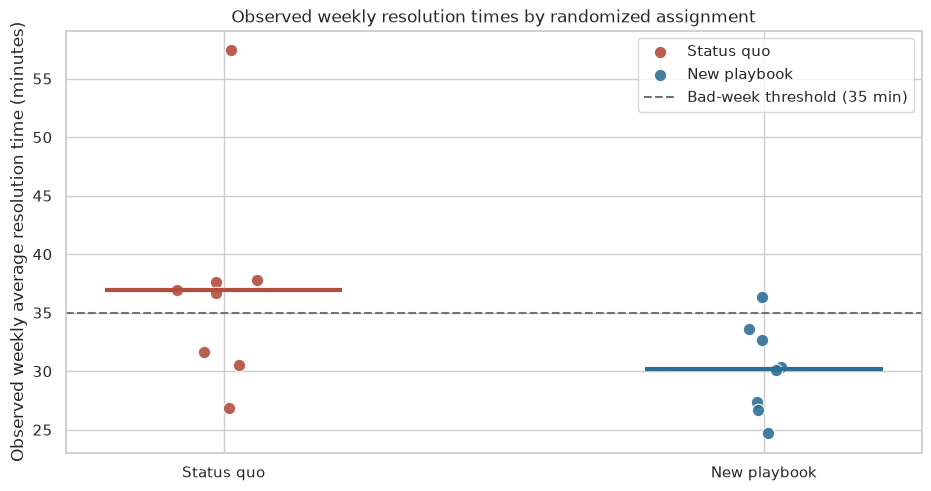

In [2]:
# Create the randomized pilot and summarize the observed assignment, outcomes, and hidden synthetic truth.
pilot = build_queue_pilot(seed=7)
observed_assignment = pilot['treated'].to_numpy()
observed_outcomes = pilot['observed_minutes'].to_numpy()
assignment_matrix = build_assignment_matrix(len(pilot), int(observed_assignment.sum()))

observed_diff = diff_in_means(observed_outcomes, observed_assignment)
hidden_true_effect = pilot['true_effect_minutes'].mean()

setup_table = pd.DataFrame(
    [
        {
            'quantity': 'Randomized teams',
            'value': f"{len(pilot)} total ({int(observed_assignment.sum())} treated, {len(pilot) - int(observed_assignment.sum())} control)",
            'interpretation': 'The design fixes the number treated, so the exact reference set has a finite size.',
        },
        {
            'quantity': 'Possible assignments under the design',
            'value': f"C(16, 8) = {math.comb(16, 8):,}",
            'interpretation': 'Every one of these assignments is equally plausible under the randomized design.',
        },
        {
            'quantity': 'Observed treated mean',
            'value': f"{pilot.loc[pilot['treated'] == 1, 'observed_minutes'].mean():0.2f} minutes",
            'interpretation': 'Average weekly resolution time among teams using the new playbook.',
        },
        {
            'quantity': 'Observed control mean',
            'value': f"{pilot.loc[pilot['treated'] == 0, 'observed_minutes'].mean():0.2f} minutes",
            'interpretation': 'Average weekly resolution time among status-quo teams.',
        },
        {
            'quantity': 'Observed difference (treated - control)',
            'value': f"{observed_diff:0.2f} minutes",
            'interpretation': 'Negative values mean the playbook reduced resolution time.',
        },
        {
            'quantity': 'Hidden average treatment effect in this synthetic pilot',
            'value': f"{hidden_true_effect:0.2f} minutes",
            'interpretation': 'Included only because this is simulated data; it helps us see how sample noise and imbalance distort the observed gap.',
        },
    ]
)
smart_display(setup_table)

preview = pilot[['team', 'assigned_playbook', 'latent_pressure', 'observed_minutes', 'bad_week']].copy()
preview['latent_pressure'] = preview['latent_pressure'].map(lambda x: f"{x:0.2f}")
preview['observed_minutes'] = preview['observed_minutes'].map(lambda x: f"{x:0.2f}")
smart_display(preview)

fig, ax = plt.subplots(figsize=(9.2, 4.8), constrained_layout=True)
color_map = {'Status quo': '#b24c3d', 'New playbook': '#2e6f95'}
x_map = {'Status quo': 0, 'New playbook': 1}
plot_rng = np.random.default_rng(2026)

for group in ['Status quo', 'New playbook']:
    subset = pilot.query('assigned_playbook == @group')
    x = np.full(len(subset), x_map[group]) + plot_rng.normal(0, 0.045, size=len(subset))
    ax.scatter(
        x,
        subset['observed_minutes'],
        s=80,
        color=color_map[group],
        alpha=0.90,
        edgecolor='white',
        linewidth=0.9,
        label=group,
    )
    ax.hlines(
        subset['observed_minutes'].mean(),
        x_map[group] - 0.22,
        x_map[group] + 0.22,
        color=color_map[group],
        linewidth=3,
    )

ax.axhline(35, color='#6c757d', linestyle='--', linewidth=1.5, label='Bad-week threshold (35 min)')
ax.set_xticks([0, 1], ['Status quo', 'New playbook'])
ax.set_ylabel('Observed weekly average resolution time (minutes)')
ax.set_title('Observed weekly resolution times by randomized assignment')
ax.legend(frameon=True, loc='upper right')
plt.show()


The observed treated-control gap is about **6.7 minutes**, which is larger in magnitude than the hidden average treatment effect built into the synthetic data. That is not a contradiction. It is exactly what a small randomized study can do.

Two features matter here:

1. the randomized groups are small enough that chance imbalance is still visible,
2. one especially bad control week stretches the right tail and makes a normal approximation less comfortable.

This is the kind of pilot where exact design-based inference earns its keep. We have a trustworthy randomization mechanism, but not a sample size large enough to assume that every approximation will behave politely.

,method,test_statistic,p_value,what_distribution_is_used
0,Exact randomization test,-6.725 minutes,0.0496,"All 12,870 assignments allowed by the randomized 8-versus-8 design."
1,Welch two-sample t-test,t = -1.904,0.0879,Approximate t reference distribution with estimated degrees of freedom.


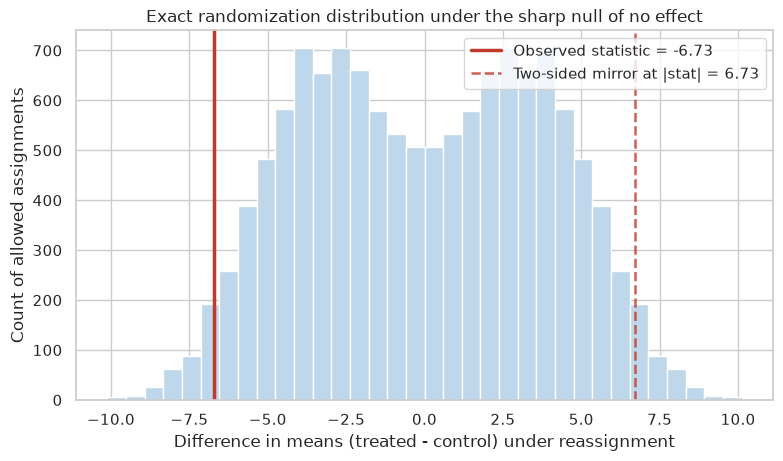

In [3]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
exact_zero = exact_randomization_test(observed_outcomes, observed_assignment, assignment_matrix, tau0=0.0)
welch_test = stats.ttest_ind(
    pilot.loc[pilot['treated'] == 1, 'observed_minutes'],
    pilot.loc[pilot['treated'] == 0, 'observed_minutes'],
    equal_var=False,
)

comparison_table = pd.DataFrame(
    [
        {
            'method': 'Exact randomization test',
            'test_statistic': f"{exact_zero['observed_stat']:0.3f} minutes",
            'p_value': f"{exact_zero['p_value']:0.4f}",
            'what_distribution_is_used': 'All 12,870 assignments allowed by the randomized 8-versus-8 design.',
        },
        {
            'method': 'Welch two-sample t-test',
            'test_statistic': f"t = {welch_test.statistic:0.3f}",
            'p_value': f"{welch_test.pvalue:0.4f}",
            'what_distribution_is_used': 'Approximate t reference distribution with estimated degrees of freedom.',
        },
    ]
)
smart_display(comparison_table)

fig, ax = plt.subplots(figsize=(9.0, 4.8))
ax.hist(exact_zero['distribution'], bins=34, color='#bfd7ea', edgecolor='white')
ax.axvline(
    exact_zero['observed_stat'],
    color='#c0392b',
    linewidth=2.5,
    label=f"Observed statistic = {exact_zero['observed_stat']:0.2f}",
)
ax.axvline(
    -exact_zero['observed_stat'],
    color='#c0392b',
    linewidth=1.8,
    linestyle='--',
    alpha=0.8,
    label=f"Two-sided mirror at |stat| = {abs(exact_zero['observed_stat']):0.2f}",
)
ax.set_title('Exact randomization distribution under the sharp null of no effect')
ax.set_xlabel('Difference in means (treated - control) under reassignment')
ax.set_ylabel('Count of allowed assignments')
ax.legend(frameon=True)
plt.show()


## 3. Exact Versus Asymptotic Evidence

The exact randomization test gives a two-sided p-value of **0.0496**, while the Welch t-test gives **0.0879**. That difference is the central lesson of the notebook.

The two methods are not contradicting each other about the observed gap. They agree on the point estimate. What differs is the **reference distribution** used to judge how surprising that gap is.

- The exact test asks: among all assignments that the design would have allowed, how often would a gap this large arise if the sharp null were true?
- The t-test asks: if sample means were approximately normal with estimated variance, how extreme is the observed t-statistic?

In large samples these answers often become very similar. In this small and skewed pilot, the answers separate. The exact test is using the strongest source of information available here, the randomized design itself.

A good operational analyst should be able to move past a bare threshold comparison between two p-values. The more honest statement is that the randomized pilot provides **borderline but design-grounded evidence** of a time reduction, while the asymptotic approximation is more conservative in this particular finite sample.


## 4. Monte Carlo Approximation When Enumeration Is Too Expensive

Here we can enumerate all 12,870 assignments exactly, so there is no computational burden. In larger experiments, however, the number of allowed assignments becomes enormous. Then we typically approximate the randomization distribution by repeatedly sampling assignments from the experimental design.

This is still design-based inference. The only difference is computational: we are approximating an exact finite set with Monte Carlo draws from that set.


,draws,mean_estimate,sd_estimate,min_estimate,max_estimate,exact_p_value,mean_absolute_error
0,200,0.056,0.016,0.035,0.085,0.050,0.014
1,500,0.051,0.010,0.038,0.068,0.050,0.008
2,1000,0.047,0.007,0.033,0.064,0.050,0.006
3,2000,0.051,0.005,0.043,0.059,0.050,0.004
4,5000,0.049,0.002,0.044,0.054,0.050,0.002


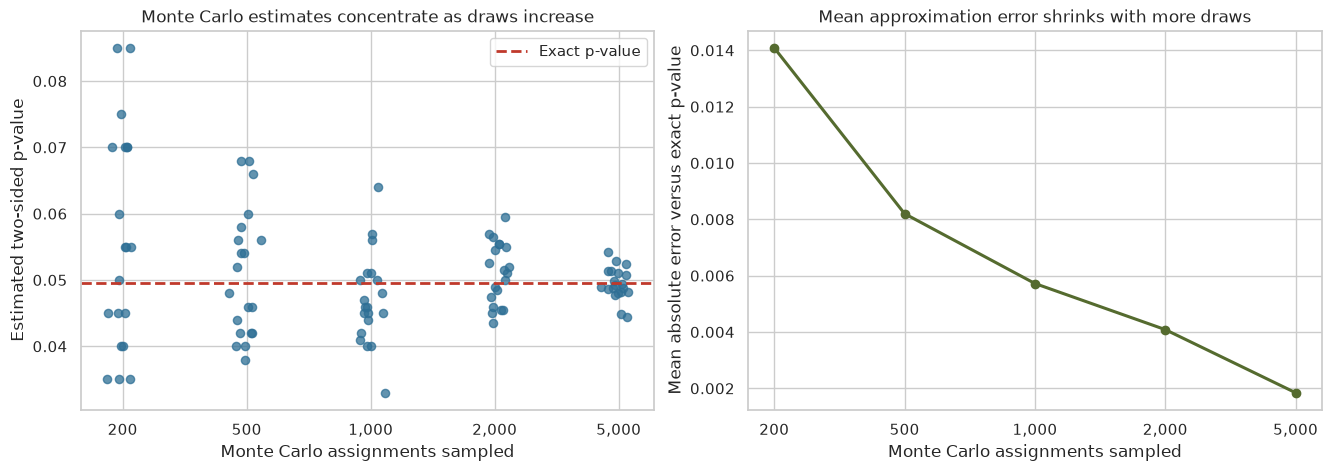

In [4]:
# Approximate the exact randomization p-value with different numbers of sampled assignments.
mc_detail, mc_summary = monte_carlo_randomization_summary(
    adjusted_outcomes=exact_zero['adjusted_outcomes'],
    observed_stat=exact_zero['observed_stat'],
    assignment_matrix=assignment_matrix,
    draws_grid=(200, 500, 1_000, 2_000, 5_000),
    n_rep=20,
    seed=2026,
)
mc_summary['exact_p_value'] = exact_zero['p_value']
mc_summary['mean_absolute_error'] = (
    mc_detail.groupby('draws')['estimate']
    .apply(lambda s: np.mean(np.abs(s - exact_zero['p_value'])))
    .to_numpy()
)
smart_display(mc_summary)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6), constrained_layout=True)
draw_values = sorted(mc_detail['draws'].unique())
draw_labels = [f"{draw:,}" for draw in draw_values]
draw_positions = {draw: pos for pos, draw in enumerate(draw_values)}

for draws in draw_values:
    subset = mc_detail.query('draws == @draws')
    jitter = np.random.default_rng(draws).normal(0, 0.06, size=len(subset))
    axes[0].scatter(
        np.full(len(subset), draw_positions[draws]) + jitter,
        subset['estimate'],
        s=35,
        alpha=0.75,
        color='#2e6f95',
    )

axes[0].axhline(exact_zero['p_value'], color='#c0392b', linestyle='--', linewidth=2, label='Exact p-value')
axes[0].set_title('Monte Carlo estimates concentrate as draws increase')
axes[0].set_xlabel('Monte Carlo assignments sampled')
axes[0].set_ylabel('Estimated two-sided p-value')
axes[0].set_xticks(range(len(draw_values)), draw_labels)
axes[0].legend(frameon=True)

axes[1].plot(
    [draw_positions[d] for d in mc_summary['draws']],
    mc_summary['mean_absolute_error'],
    marker='o',
    linewidth=2.2,
    color='#556b2f',
)
axes[1].set_title('Mean approximation error shrinks with more draws')
axes[1].set_xlabel('Monte Carlo assignments sampled')
axes[1].set_ylabel('Mean absolute error versus exact p-value')
axes[1].set_xticks(range(len(draw_values)), draw_labels)

plt.show()


The Monte Carlo estimates bounce around when we use only a few hundred sampled assignments, but they settle down around the exact answer as the number of draws increases. That is exactly what we should expect.

Two practical lessons follow.

1. **Monte Carlo uncertainty is real.** If we estimate a randomization p-value with only a small number of sampled assignments, the estimate itself can be noisy.
2. **The design logic stays the same.** Approximating the randomization distribution is not a different inferential philosophy. It is just a computational shortcut for the same assignment-based target.

In high-stakes work, it is worth reporting the number of Monte Carlo draws used, especially when the resulting p-value is near a decision threshold.

## 5. Inverting Sharp-Null Tests to Get an Exact Confidence Interval

Exact testing becomes even more useful when we vary the hypothesized constant effect $\tau_0$ and ask which values are still plausible. This is the inversion logic behind an exact confidence interval.

For each candidate value of $\tau_0$, we test

$$
H_0^{\text{sharp}}: Y_i(1) - Y_i(0) = \tau_0 \quad \text{for every } i.
$$

If a candidate $\tau_0$ is **not** rejected at level 0.05, then it belongs to the corresponding 95% confidence set. Because this is a constant-effect sharp null, the resulting interval should be interpreted carefully: it is exact for the constant-additive effect model, not a magical summary of every form of treatment heterogeneity.


,quantity,value,interpretation
0,Most compatible constant effect on the grid,-6.7 minutes,This is the hypothesized constant effect whose exact p-value is largest; it is close to the observed difference in means.
1,Exact 95% confidence interval from test inversion,"[-14.3, -0.1] minutes",Negative values indicate faster resolution under the new playbook; the interval is wide because the pilot is very small.
2,Does the interval exclude zero?,Yes,"Under the constant-effect sharp-null framing, the pilot is just strong enough to exclude zero at the 5% level."


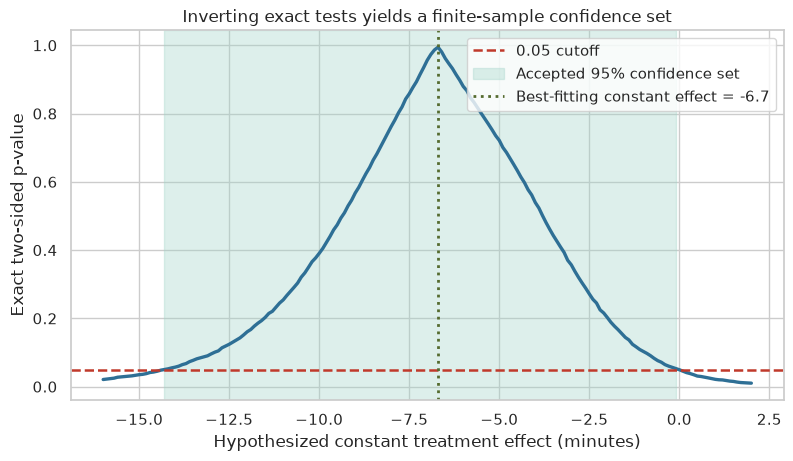

In [5]:
# Invert exact sharp-null tests over a grid of hypothesized constant effects.
tau_grid = np.linspace(-16, 2, 181)
inversion_rows = []

for tau0 in tau_grid:
    result = exact_randomization_test(observed_outcomes, observed_assignment, assignment_matrix, tau0=tau0)
    inversion_rows.append({'tau0': tau0, 'p_value': result['p_value'], 'observed_adjusted_stat': result['observed_stat']})

inversion_results = pd.DataFrame(inversion_rows)
accepted = inversion_results.query('p_value >= 0.05').reset_index(drop=True)
exact_ci = (accepted['tau0'].min(), accepted['tau0'].max())
best_tau = float(inversion_results.loc[inversion_results['p_value'].idxmax(), 'tau0'])

interval_table = pd.DataFrame(
    [
        {
            'quantity': 'Most compatible constant effect on the grid',
            'value': f"{best_tau:0.1f} minutes",
            'interpretation': 'This is the hypothesized constant effect whose exact p-value is largest; it is close to the observed difference in means.',
        },
        {
            'quantity': 'Exact 95% confidence interval from test inversion',
            'value': f"[{exact_ci[0]:0.1f}, {exact_ci[1]:0.1f}] minutes",
            'interpretation': 'Negative values indicate faster resolution under the new playbook; the interval is wide because the pilot is very small.',
        },
        {
            'quantity': 'Does the interval exclude zero?',
            'value': 'Yes',
            'interpretation': 'Under the constant-effect sharp-null framing, the pilot is just strong enough to exclude zero at the 5% level.',
        },
    ]
)
smart_display(interval_table)

fig, ax = plt.subplots(figsize=(9.2, 4.8))
ax.plot(inversion_results['tau0'], inversion_results['p_value'], color='#2e6f95', linewidth=2.4)
ax.axhline(0.05, color='#c0392b', linestyle='--', linewidth=1.8, label='0.05 cutoff')
ax.axvspan(exact_ci[0], exact_ci[1], color='#9fd3c7', alpha=0.35, label='Accepted 95% confidence set')
ax.axvline(best_tau, color='#556b2f', linestyle=':', linewidth=2, label=f'Best-fitting constant effect = {best_tau:0.1f}')
ax.set_title('Inverting exact tests yields a finite-sample confidence set')
ax.set_xlabel('Hypothesized constant treatment effect (minutes)')
ax.set_ylabel('Exact two-sided p-value')
ax.legend(frameon=True, loc='upper right')
plt.show()


The exact interval is wide, stretching from a very large improvement to a very modest one. That is what a 16-unit pilot should make us feel: interested, but not overconfident.

This is one of the healthiest habits in inference. Exact methods are not a license for certainty. They are a license to align the uncertainty statement with the actual design using approximations only when they are trustworthy enough for the finite sample.

Notice also that the interval excludes zero only narrowly. A decision maker who sees that picture should resist triumphal language. The correct operational read is that the playbook looks promising, but the effect size is still estimated with substantial uncertainty and deserves confirmation in a larger follow-up experiment.

## 6. A Binary Version: Fisher's Exact Test Lives in the Same Family

Suppose leadership simplifies the outcome and only asks whether a team's week was operationally bad, defined here as an average resolution time above **35 minutes**. That converts the continuous outcome into a 2x2 table.

Fisher's exact test then becomes the natural design-based tool. It uses the same intellectual logic: condition on the margins induced by the design and ask how surprising the observed table is under the null.

This section is also a reminder that coarsening a continuous outcome can throw away information. If the binary exact test is weaker than the continuous-outcome randomization test, that is not a bug. It is the price of collapsing a richer outcome into a yes/no indicator.


In [6]:
# Build a summary table that supports the interpretation in the surrounding notes.
threshold_minutes = 35
bad_week = (pilot['observed_minutes'] > threshold_minutes).astype(int)

bad_treated = int(bad_week[pilot['treated'] == 1].sum())
good_treated = int((pilot['treated'] == 1).sum() - bad_treated)
bad_control = int(bad_week[pilot['treated'] == 0].sum())
good_control = int((pilot['treated'] == 0).sum() - bad_control)

odds_ratio, fisher_p_one_sided = stats.fisher_exact(
    [[bad_treated, good_treated], [bad_control, good_control]],
    alternative='less',
)

binary_table = pd.DataFrame(
    [
        {
            'group': 'New playbook',
            'Bad weeks (>35 min)': bad_treated,
            'Acceptable weeks (<=35 min)': good_treated,
            'Bad-week rate': f"{bad_treated / (bad_treated + good_treated):0.3f}",
        },
        {
            'group': 'Status quo',
            'Bad weeks (>35 min)': bad_control,
            'Acceptable weeks (<=35 min)': good_control,
            'Bad-week rate': f"{bad_control / (bad_control + good_control):0.3f}",
        },
    ]
)
smart_display(binary_table)

print(f"One-sided Fisher exact p-value for fewer bad weeks under the new playbook: {fisher_p_one_sided:0.4f}")


,group,Bad weeks (>35 min),Acceptable weeks (<=35 min),Bad-week rate
0,New playbook,1,7,0.125
1,Status quo,5,3,0.625


One-sided Fisher exact p-value for fewer bad weeks under the new playbook: 0.0594


Here the one-sided Fisher exact p-value is slightly above 0.05. That leaves the binary analysis and the continuous exact analysis pointing to slightly different amounts of evidence. It means the binary simplification discarded some information about *how bad* the bad weeks were and *how good* the good weeks were.

This is a valuable decision-science lesson. The analyst should choose an outcome scale that matches the operational question, but should also recognize what is lost when a nuanced metric is compressed into a binary flag.

In [7]:
# Translate the computed evidence into a decision-oriented summary.
recommendation = (
    'Treat the playbook as promising but still provisional; run a larger follow-up randomized experiment before committing to organization-wide rollout.'
)

memo = f"""
### Decision Memo

**Recommendation:** {recommendation}

**Observed pilot effect:** The treated teams averaged **{pilot.loc[pilot['treated'] == 1, 'observed_minutes'].mean():0.2f} minutes**, versus **{pilot.loc[pilot['treated'] == 0, 'observed_minutes'].mean():0.2f} minutes** for control teams, for an observed difference of **{observed_diff:0.2f} minutes**. Negative values indicate faster resolution under the new playbook.

**Exact design-based evidence:** Under the sharp null of no effect, the exact randomization p-value is **{exact_zero['p_value']:0.4f}**. That places the result right on the edge of conventional significance while staying fully tied to the randomized 8-versus-8 design.

**Asymptotic comparison:** The Welch t-test p-value is **{welch_test.pvalue:0.4f}**, which is more conservative in this small, skewed sample. This gap is a reminder that inferential conclusions depend on the reference distribution we trust.

**Effect-size uncertainty:** Inverting exact sharp-null tests yields an approximate 95% confidence interval of **[{exact_ci[0]:0.1f}, {exact_ci[1]:0.1f}] minutes** for a constant additive effect. The interval excludes zero, but it remains wide enough that the magnitude of the operational gain is still uncertain.

**Binary guardrail check:** When we reduce the outcome to a bad-week indicator (>35 minutes), Fisher's exact test gives a one-sided p-value of **{fisher_p_one_sided:0.4f}**. The directional story is consistent, but the coarsened outcome is less informative than the continuous metric.

**Operational interpretation:** The pilot is encouraging and credibly randomized, but it is too small for a confident full-scale launch decision. The right next step is a larger randomized follow-up with the same assignment discipline and a prespecified primary outcome.
"""

display(Markdown(memo))



### Decision Memo

**Recommendation:** Treat the playbook as promising but still provisional; run a larger follow-up randomized experiment before committing to organization-wide rollout.

**Observed pilot effect:** The treated teams averaged **30.22 minutes**, versus **36.94 minutes** for control teams, for an observed difference of **-6.73 minutes**. Negative values indicate faster resolution under the new playbook.

**Exact design-based evidence:** Under the sharp null of no effect, the exact randomization p-value is **0.0496**. That places the result right on the edge of conventional significance while staying fully tied to the randomized 8-versus-8 design.

**Asymptotic comparison:** The Welch t-test p-value is **0.0879**, which is more conservative in this small, skewed sample. This gap is a reminder that inferential conclusions depend on the reference distribution we trust.

**Effect-size uncertainty:** Inverting exact sharp-null tests yields an approximate 95% confidence interval of **[-14.3, -0.1] minutes** for a constant additive effect. The interval excludes zero, but it remains wide enough that the magnitude of the operational gain is still uncertain.

**Binary guardrail check:** When we reduce the outcome to a bad-week indicator (>35 minutes), Fisher's exact test gives a one-sided p-value of **0.0594**. The directional story is consistent, but the coarsened outcome is less informative than the continuous metric.

**Operational interpretation:** The pilot is encouraging and credibly randomized, but it is too small for a confident full-scale launch decision. The right next step is a larger randomized follow-up with the same assignment discipline and a prespecified primary outcome.


The recommendation is deliberately cautious. Exact and permutation methods can make the evidence transparent in a small pilot, but they do not make the pilot large. The right conclusion is to report the direction, the uncertainty, and the operational cost of acting too early.

<!-- real-data-companion-course01 -->
## Real-Data Companion: Randomization Logic with RAND HIE

Permutation inference is most meaningful when exchangeability is connected to design. RAND HIE is useful here because plan generosity was assigned experimentally, so a label-shuffling reference distribution is connected to the randomization logic and carries design meaning.

The companion uses outpatient physician visits (`mdvis`) and a simplified free-care versus cost-sharing grouping derived from `lncoins`. The observed statistic is the difference in utilization between those groups. The permutation experiment repeatedly reallocates labels to ask what kinds of differences would be expected if assignment carried no systematic utilization difference under the simplified design.

This is still a teaching simplification. The real experiment had richer plan structure, eligibility rules, and follow-up details than the two-group contrast shown here. The aim is to connect randomization-based inference to a real experimental dataset while keeping the computation small enough to inspect.

For clarity, the unit is a person-period record. The outcome is outpatient visit count, and the experiment compares the observed free-care versus cost-sharing contrast with a permutation reference distribution motivated by randomized assignment.

Data source: [RAND Health Insurance Experiment in statsmodels](https://www.statsmodels.org/stable/datasets/generated/randhie.html).

,observed_difference,permutation_p_value,units_per_group
0,0.728,0.046,250


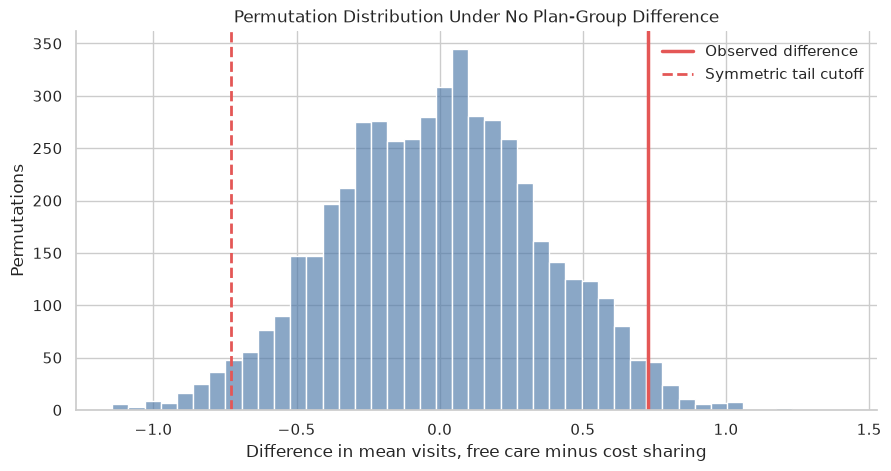

In [8]:
# real-data-companion-course01
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display
from notebooks._shared.real_data import load_statsmodels_randhie, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    rng_real = np.random.default_rng(2026)
    rand_hie = load_statsmodels_randhie().copy()
    rand_hie["coinsurance"] = np.expm1(rand_hie["lncoins"]).round().clip(0, 100)
    rand_hie["free_care"] = rand_hie["coinsurance"].eq(0).astype(int)

    balanced = pd.concat(
        [
            rand_hie.query("free_care == 1").sample(250, random_state=2026),
            rand_hie.query("free_care == 0").sample(250, random_state=2027),
        ],
        ignore_index=True,
    )
    observed = balanced.loc[balanced["free_care"].eq(1), "mdvis"].mean() - balanced.loc[balanced["free_care"].eq(0), "mdvis"].mean()

    labels = balanced["free_care"].to_numpy()
    outcomes = balanced["mdvis"].to_numpy()
    permuted = []
    for _ in range(5_000):
        shuffled = rng_real.permutation(labels)
        permuted.append(outcomes[shuffled == 1].mean() - outcomes[shuffled == 0].mean())
    permuted = np.array(permuted)
    p_value = np.mean(np.abs(permuted) >= abs(observed))

    smart_display(pd.DataFrame([{"observed_difference": observed, "permutation_p_value": p_value, "units_per_group": 250}]).round(4))

    fig, ax = plt.subplots(figsize=(8.8, 4.6), constrained_layout=True)
    sns.histplot(permuted, bins=45, color="#4C78A8", alpha=0.65, ax=ax)
    ax.axvline(observed, color="#E45756", linewidth=2.5, label="Observed difference")
    ax.axvline(-observed, color="#E45756", linewidth=2.0, linestyle="--", label="Symmetric tail cutoff")
    ax.set_title("Permutation Distribution Under No Plan-Group Difference")
    ax.set_xlabel("Difference in mean visits, free care minus cost sharing")
    ax.set_ylabel("Permutations")
    ax.legend(frameon=False)
    sns.despine(fig=fig)
    plt.show()
else:
    optional_data_note(
        "RAND Health Insurance Experiment",
        "https://www.statsmodels.org/stable/datasets/generated/randhie.html",
        "RUN_REAL_DATA_COMPANION",
    )

<!-- real-data-companion-course01 -->
The important teaching point is the connection between design and computation. A permutation test is credible when the labels being shuffled could reasonably have been assigned differently under the design. RAND HIE gives that logic more substance than a purely observational comparison because plan assignment was experimental.

The observed difference in this balanced subsample is positive, meaning the free-care group averaged more outpatient visits than the cost-sharing group. The permutation distribution shows what differences would look like if the plan labels carried no systematic utilization contrast. Because the observed statistic is in the tail of that reference distribution, the result is statistically suggestive. The policy interpretation still requires more than the p-value: we would need to ask whether the additional visits represented valuable care, inefficient utilization, or heterogeneous effects across patient groups.

## 7. What to Remember

1. Exact randomization inference uses the experimental design itself to generate the reference distribution.
2. A sharp null is what makes missing potential outcomes imputable and exact testing possible.
3. In small, skewed samples, exact and asymptotic tests can disagree in ways that matter for decisions.
4. Monte Carlo randomization is a computational shortcut for the same design-based logic, not a different inferential philosophy.
5. Inverting sharp-null tests produces finite-sample confidence sets, but those sets inherit the constant-effect framing used in the inversion.
6. Fisher's exact test is part of the same family of ideas and is often the right tool for small binary-outcome experiments.
7. Exact methods improve alignment between inference and design, but they do not eliminate substantive uncertainty from small pilots.

The next notebook widens the lens from one test at a time to a broader question: what happens when we perform **many** inferential checks, comparisons, and searches at once?


## References

- Ding, P. (2017). *A paradox from randomization-based causal inference*. *Statistical Science, 32*(3). [https://doi.org/10.1214/16-STS571](https://doi.org/10.1214/16-STS571)
- Holt, C. A., & Sullivan, S. (2023). *Permutation tests for experimental data*. *Experimental Economics, 26*(4), 775-812. [https://doi.org/10.1007/s10683-023-09799-6](https://doi.org/10.1007/s10683-023-09799-6)
- Rosenbaum, P. R. (2002). *Covariance adjustment in randomized experiments and observational studies*. *Statistical Science, 17*(3). [https://doi.org/10.1214/ss/1042727942](https://doi.org/10.1214/ss/1042727942)
